In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd, norm
from matplotlib.colors import LogNorm
from numba import njit
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from utilities_rbf import compute_relative_L2_error, local_orders, sampling_domain_2d

# -------------------------
# Parameters
# -------------------------
N_side = 20
N = N_side**2 # Total N for dimensions. 
T = 8.0
zeta = int(2.0)
M_side = int(np.sqrt(zeta * N))        
tau = 1e-15
M = M_side**2 # Total collocation points for all dimensions. 

sampling_choice = 'random' # 'uniform' grid or 'random' sampling on grid
seed_value = 123456 # seed for random sampling 
sigma_scale_random_sampling = 1e-8



def c_from_T(T, tau):
    return np.pi / (T * np.sqrt(2 * np.log(1 + tau**(-2))))

c = c_from_T(T, tau)
print(f'c value using c(T, tau): {c:.3f}')
b = c * N
print(f"b (kernel shape) = {b:.3f}")

max_iter = 50_000
tol = 1e-6
L = 1.0

# ADMM/BC params
rho = 20.3          # ADMM penalty
h = L/M_side 
mu  = 10/(h**2)             # <-- set mu>0 for soft thresholding; mu=0 = hard projection
beta_bc = 1e6        # Dirichlet penalty 
eps_reg = 0.0       # tiny Tikhonov on lhs, 0.0 --> no regularization. 
alpha = 1.0           # over-relaxation (1.0 = off)

# -------------------------
# Domain
# -------------------------
#x = np.linspace(0, L, M_side)
#X, Y = np.meshgrid(x, x)
#collocation_pts = np.column_stack((X.ravel(), Y.ravel()))

X, Y, collocation_pts, boundary_mask, interior_mask = sampling_domain_2d(M_side, M_side, 
                                                                         seed_x = seed_value, 
                                                                         seed_y = seed_value, 
                                                                        jitter_frac = sigma_scale_random_sampling)

# RBF centers (keep them close to domain for conditioning)
lower_a, upper_b = 0, L
L_half = 0.5 * (upper_b - lower_a)
q_mid = 0.5 * (lower_a + upper_b)
T_cent = 1.0
cx = np.linspace(q_mid - T_cent * L_half, q_mid + T_cent * L_half, N_side)
CY, CX = np.meshgrid(cx, cx)
centers = np.column_stack((CX.ravel(), CY.ravel()))

# -------------------------
# Problem switch
# -------------------------
pi = np.pi
problem = '2'  # '1' = sin-sin; '2' = dome obstacle

def g_zero_boundary(xy):
    return np.zeros(xy.shape[0], dtype=float)

def psi_sinsin(xy, height=0.05):
    x, y = xy[:, 0], xy[:, 1]
    vals = (1 / (2 * pi * pi)) * np.sin(pi * x) * np.sin(pi * y)
    return np.minimum(vals, height)

def u_true_sinsin(xy):
    x, y = xy[:, 0], xy[:, 1]
    return (1 / (2 * pi * pi)) * np.sin(pi * x) * np.sin(pi * y)

# -------------------------
# Radial dome: exact psi and u (disk continuation)
# -------------------------
H = 1.0
CENTER = (0.5, 0.5)
rc = 0.5
R = 1.0  # outer radius for analytic continuation (u harmonic for r in (r*,R], 0 beyond R)

def _r(xy, center=CENTER):
    x, y = xy[:, 0] - center[0], xy[:, 1] - center[1]
    return np.sqrt(x * x + y * y)

# Solve for contact radius r* via t in (0,1): f(t)=0; r* = rc*sqrt(t*)
# f(t) = t ln t + 2 t ln(rc/R) + 1 - t
def _solve_r_star(rc, R, tol=1e-12, maxit=200):
    if not (0.0 < rc < R):
        raise ValueError("Require 0 < rc < R.")
    def f(t):
        return t * np.log(t) + 2.0 * t * np.log(rc / R) + 1.0 - t
    a, b = 1e-15, 1.0 - 1e-15
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        a, b = 1e-12, 1.0 - 1e-12
        fa, fb = f(a), f(b)
        if fa * fb > 0:
            raise RuntimeError("Root not bracketed on (0,1).")
    for _ in range(maxit):
        m = 0.5 * (a + b)
        fm = f(m)
        if abs(fm) < tol or (b - a) < tol:
            t_star = m
            break
        if fm > 0.0:  # f decreasing on (0,1)
            a, fa = m, fm
        else:
            b, fb = m, fm
    else:
        t_star = m
    return rc * np.sqrt(t_star)

r_star = _solve_r_star(rc, R)

def psi_dome(xy, H = H, rc = rc):
    r = _r(xy)
    out = H * (1.0 - (r / rc) ** 2)
    out[r > rc] = 0.0
    return out

# u = ψ for r ≤ r*, harmonic for r* < r ≤ R; u=0 for r ≥ R
def u_true_dome(xy):
    r = _r(xy)
    u = np.zeros_like(r)
    inside = r <= r_star
    ring = (r > r_star) & (r <= R)
    u[inside] = H * (1.0 - (r[inside] / rc) ** 2)
    if np.any(ring):
        coeff = (2.0 * H * (r_star ** 2) / (rc ** 2))
        base = H * (1.0 - (r_star ** 2) / (rc ** 2))
        rr = r[ring]
        u[ring] = base - coeff * np.log(rr / r_star)
    return u

# -------------------------
# Pick obstacle/exact & boundary data
# -------------------------
if problem == '1':
    psi_vals = psi_sinsin(collocation_pts)
    u_exact = u_true_sinsin(collocation_pts)
    g_bc = g_zero_boundary(collocation_pts)  # homogeneous BC
elif problem == '2':
    psi_vals = psi_dome(collocation_pts)
    u_exact = u_true_dome(collocation_pts)
    # exact dome values on the square boundary (so analytic and numerical match)
    # g_bc will be sliced to boundary points below
else:
    raise ValueError("problem must be '1' or '2'.")

# -------------------------
# Numba-accelerated RBFs
# -------------------------
@njit
def rbf_fast(xy, centers, b):
    M, N = xy.shape[0], centers.shape[0]
    out = np.empty((M, N))
    for i in range(M):
        for j in range(N):
            dx = xy[i, 0] - centers[j, 0]
            dy = xy[i, 1] - centers[j, 1]
            r2 = dx * dx + dy * dy
            out[i, j] = np.exp(-b * b * r2)
    return out

@njit
def rbf_grad_fast(xy, centers, b):
    """
    Gradients of Gaussian RBF: phi = exp(-b^^2 r^2)
      dphi/dx = -2 b^2 (x - cx) * phi
      dphi/dy = -2 b^2 (y - cy) * phi
    Returns Gx, Gy with shape (M, N)
    """
    M, N = xy.shape[0], centers.shape[0]
    Gx = np.empty((M, N))
    Gy = np.empty((M, N))
    for i in range(M):
        xi, yi = xy[i, 0], xy[i, 1]
        for j in range(N):
            dx = xi - centers[j, 0]
            dy = yi - centers[j, 1]
            r2 = dx * dx + dy * dy
            phi = np.exp(-b * b * r2)
            coef = -2.0 * b * b
            Gx[i, j] = coef * dx * phi
            Gy[i, j] = coef * dy * phi
    return Gx, Gy

Phi_raw = rbf_fast(collocation_pts, centers, b)
Phi = Phi_raw / np.sqrt(N)

Gx_raw, Gy_raw = rbf_grad_fast(collocation_pts, centers, b)
Gx = Gx_raw / np.sqrt(N)
Gy = Gy_raw / np.sqrt(N)

dx = L / (M_side)

# Energy (weak form)
A1 = dx**2 * (Gx.T @ Gx + Gy.T @ Gy)

# -------------------------
# Boundary masks & data
# -------------------------
boundary_mask = (np.isclose(collocation_pts[:, 0], 0) |
                 np.isclose(collocation_pts[:, 0], L) |
                 np.isclose(collocation_pts[:, 1], 0) |
                 np.isclose(collocation_pts[:, 1], L))
interior_mask = ~boundary_mask

Phi_bc = Phi[boundary_mask, :]

if problem == '1':
    g_bc = g_zero_boundary(collocation_pts[boundary_mask])
elif problem == '2':
    g_bc = u_true_dome(collocation_pts[boundary_mask])  # exact dome on boundary

# -------------------------
# Normal equations (lhs) for w-update
# -------------------------
A = A1 + beta_bc * (Phi_bc.T @ Phi_bc)
lhs = A + rho * (Phi.T @ Phi) + eps_reg * np.eye(N)

# TSVD solver
U, S, VT = svd(lhs, full_matrices=False)
svd_tol = tau * np.max(S)
S_inv = np.where(S > svd_tol, 1.0 / S, 0.0)

def svd_solve(U, S_inv, VT, bvec):
    return VT.T @ (S_inv * (U.T @ bvec))

# -------------------------
# ADMM initialization
# -------------------------
w = np.zeros(N)
v = Phi @ w
z = np.zeros(M)
primal_residuals, dual_residuals = [], []

# Early-stopping (stall) hyper-params
stall_rel = 5e-7
stall_patience = 10_000
tiny = 1e-30
best_prim = np.inf
best_dual = np.inf
stall_cnt = 0

# -------------------------
# ADMM iteration
# -------------------------
for it in range(max_iter):
    # w-update (quadratic solve)
    rhs = rho * Phi.T @ (v - z) + beta_bc * (Phi_bc.T @ g_bc)
    w_new = svd_solve(U, S_inv, VT, rhs)

    # v-update
    a = alpha * (Phi @ w_new) + (1 - alpha) * v + z

    v_new = a.copy()

    # ----- boundary: hard clamp -----
    v_new[boundary_mask] = g_bc

    # ----- interior: obstacle -----
    a_int   = a[interior_mask]
    psi_int = psi_vals[interior_mask]

    if mu <= 0:  # HARD projection (recommended)
        v_new[interior_mask] = np.maximum(a_int, psi_int)
    else:        # SOFT obstacle (Moreau–Yosida)
        below = a_int < psi_int
        v_soft = (rho * a_int + mu * psi_int) / (rho + mu)
        v_int  = a_int.copy()
        v_int[below] = v_soft[below]
        v_new[interior_mask] = v_int

    # z-update: only on interior; keep boundary dual zero so it doesn't fight the clamp
    z_new = z.copy()
    residual = (Phi @ w_new - v_new)
    z_new[interior_mask] += residual[interior_mask]
    z_new[boundary_mask]  = 0.0

    # diagnostics
    r_k = Phi @ w_new - v_new
    s_k = rho * Phi.T @ (v_new - v)

    norm_u = norm(Phi @ w_new)
    norm_v = norm(v_new)
    primal_res = norm(r_k) ** 2 / max(norm_u ** 2, norm_v ** 2, tol)
    dual_res = norm(s_k) / max(norm(rho * Phi.T @ z), tol)

    primal_residuals.append(primal_res)
    dual_residuals.append(dual_res)

    if (it % 500 == 0) or (primal_res < tol and dual_res < tol):
        print(f"Iter {it}: Primal Residual = {primal_res:.2e}, Dual Residual = {dual_res:.2e}")
    if primal_res < tol and dual_res < tol:
        print(f"Converged at iteration {it}")
        w, v, z = w_new, v_new, z_new
        break

    # Early-stopping (stall detection)
    imp_prim = (best_prim - primal_res) / (best_prim if best_prim > tiny else tiny)
    imp_dual = (best_dual - dual_res)   / (best_dual if best_dual > tiny else tiny)

    improved = False
    if imp_prim > stall_rel:
        best_prim = primal_res
        improved = True
    if imp_dual > stall_rel:
        best_dual = dual_res
        improved = True

    if improved:
        stall_cnt = 0
    else:
        stall_cnt += 1
        if stall_cnt >= stall_patience:
            print(f"Early stop (stall) at iter {it}: no ≥{stall_rel:.1e} rel improvement "
                  f"in prim/dual for {stall_cnt} consecutive iterations.")
            w, v, z = w_new, v_new, z_new
            break

    w, v, z = w_new, v_new, z_new

# -------------------------
# Post-processing
# -------------------------
# For plotting and visualization. 
M_plot = 512
x_plot = np.linspace(0, L, M_plot)
X_plot, Y_plot = np.meshgrid(x_plot, x_plot)
collocation_pts_plot = np.column_stack((X_plot.ravel(), Y_plot.ravel()))
Phi_raw_plot = rbf_fast(collocation_pts_plot, centers, b)
Phi_plot = Phi_raw_plot / np.sqrt(N)
boundary_mask_plot = (np.isclose(collocation_pts_plot[:, 0], 0) |
                 np.isclose(collocation_pts_plot[:, 0], L) |
                 np.isclose(collocation_pts_plot[:, 1], 0) |
                 np.isclose(collocation_pts_plot[:, 1], L))

u_rbf = Phi_plot @ w
U_rbf = u_rbf.reshape(M_plot, M_plot)
u_exact = u_true_dome(collocation_pts_plot)
U_exact = u_exact.reshape(M_plot, M_plot)
psi_vals = psi_dome(collocation_pts_plot)
Psi = psi_vals.reshape(M_plot, M_plot)
abs_error = np.abs(U_rbf - U_exact)



c value using c(T, tau): 0.033
b (kernel shape) = 13.364
Iter 0: Primal Residual = 9.49e-01, Dual Residual = 1.24e+08


/tmp/ipykernel_763884/3496926425.py:313: RuntimeWarning: invalid value encountered in scalar divide
  imp_prim = (best_prim - primal_res) / (best_prim if best_prim > tiny else tiny)
/tmp/ipykernel_763884/3496926425.py:314: RuntimeWarning: invalid value encountered in scalar divide
  imp_dual = (best_dual - dual_res)   / (best_dual if best_dual > tiny else tiny)


Iter 500: Primal Residual = 3.93e-07, Dual Residual = 3.17e-02
Iter 1000: Primal Residual = 3.92e-07, Dual Residual = 8.17e-04
Iter 1500: Primal Residual = 3.92e-07, Dual Residual = 2.12e-05
Iter 1919: Primal Residual = 3.92e-07, Dual Residual = 9.93e-07
Converged at iteration 1919


In [2]:
# -------------------------
# Plots: obstacle (3D) & collocation points (2D)
# -------------------------
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import os 
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.labelsize': 16,
    'axes.titlesize': 20,
    'axes.linewidth': 1.0,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'lines.linewidth': 4.0,
    'grid.linestyle': '-',
    'grid.alpha': 0.5,
    'figure.dpi': 300,
})

# Ensure output dir exists
outdir = "./Outputs/2D_Obstacle/Psi_Cont"
os.makedirs(outdir, exist_ok=True)

# Ensure Psi is shaped (M_side, M_side)
if problem == '1':
    psi_vals =  psi_dome(collocation_pts_plot)
elif problem == '2':
    psi_vals = psi_dome(collocation_pts_plot)


Psi = psi_vals.reshape(M_plot, M_plot)
fig1 = plt.figure(figsize=(9.5, 7), dpi = 300)
ax0 = fig1.add_axes([0.08, 0.08, 0.88, 0.88], projection='3d')  # left, bottom, width, height
surf = ax0.plot_surface(X_plot, Y_plot, Psi, rstride=1, cstride=1, antialiased=True, 
                        linewidth=0, cmap='jet')
ax0.grid(True)
ax0.set_title(r'Obstacle $\psi(x,y)$')
ax0.set_xlabel('x'); ax0.set_ylabel('y')
fig1.colorbar(surf, ax=ax0, shrink=0.5, pad=0.05, label=r'$\psi(x,y)$')
ax0.view_init(elev=35, azim=-45)
plt.savefig(os.path.join(outdir, 'fig2_obstacle_2D_psifunc.png'), dpi=300)
plt.close()





rng = np.random.default_rng(0)  # for reproducibility
# How many to show (keep plots readable)
n_int_show = min(1500, max(200, (M_plot - 2)**2))
n_bnd_show = min(500,  4*(M_plot - 1))

# Random INTERIOR points: uniform in (0,1)^2 (open square)
eps = 1e-6
int_pts = rng.random((n_int_show, 2))
int_pts = int_pts * (1 - 2*eps) + eps  # push away from boundary

# Random BOUNDARY points: uniform along edges (x=0, x=1, y=0, y=1)
edges = rng.integers(0, 4, size=n_bnd_show)  # 0: y=0, 1: y=1, 2: x=0, 3: x=1
t = rng.random(n_bnd_show)
x_b = np.empty(n_bnd_show)
y_b = np.empty(n_bnd_show)
x_b[edges == 0] = t[edges == 0];  y_b[edges == 0] = 0.0   # bottom
x_b[edges == 1] = t[edges == 1];  y_b[edges == 1] = 1.0   # top
x_b[edges == 2] = 0.0;            y_b[edges == 2] = t[edges == 2]  # left
x_b[edges == 3] = 1.0;            y_b[edges == 3] = t[edges == 3]  # right
bnd_pts = np.column_stack([x_b, y_b])

# Plot: collocation points 
fig2 = plt.figure(figsize=(9.5, 7), dpi = 300)
ax1 = fig2.add_axes([0.08, 0.08, 0.88, 0.88])

# (rest of your random point generation stays the same)
ax1.scatter(int_pts[:, 0], int_pts[:, 1], s=10, c='green', label='interior $m_{\\Omega}$', alpha=0.9)
ax1.scatter(bnd_pts[:, 0], bnd_pts[:, 1], s=12, c='red',   label='boundary $m_{\\partial \\Omega}$', alpha=0.9)

ax1.set_title(r'Collocation Point(s)')
ax1.set_xlabel('x'); ax1.set_ylabel('y')
ax1.set_xlim(-0.01, 1.01); ax1.set_ylim(-0.01, 1.01)
ax1.set_aspect('equal', adjustable='box')
ax1.legend(loc='best', frameon=True)
plt.savefig(os.path.join(outdir, 'fig2_obstacle_2D_collocations.png'), dpi=300)
plt.close()
plt.show()


Relative L2 (domain): 1.259542e-09
Boundary mean abs error: 7.289579e-04


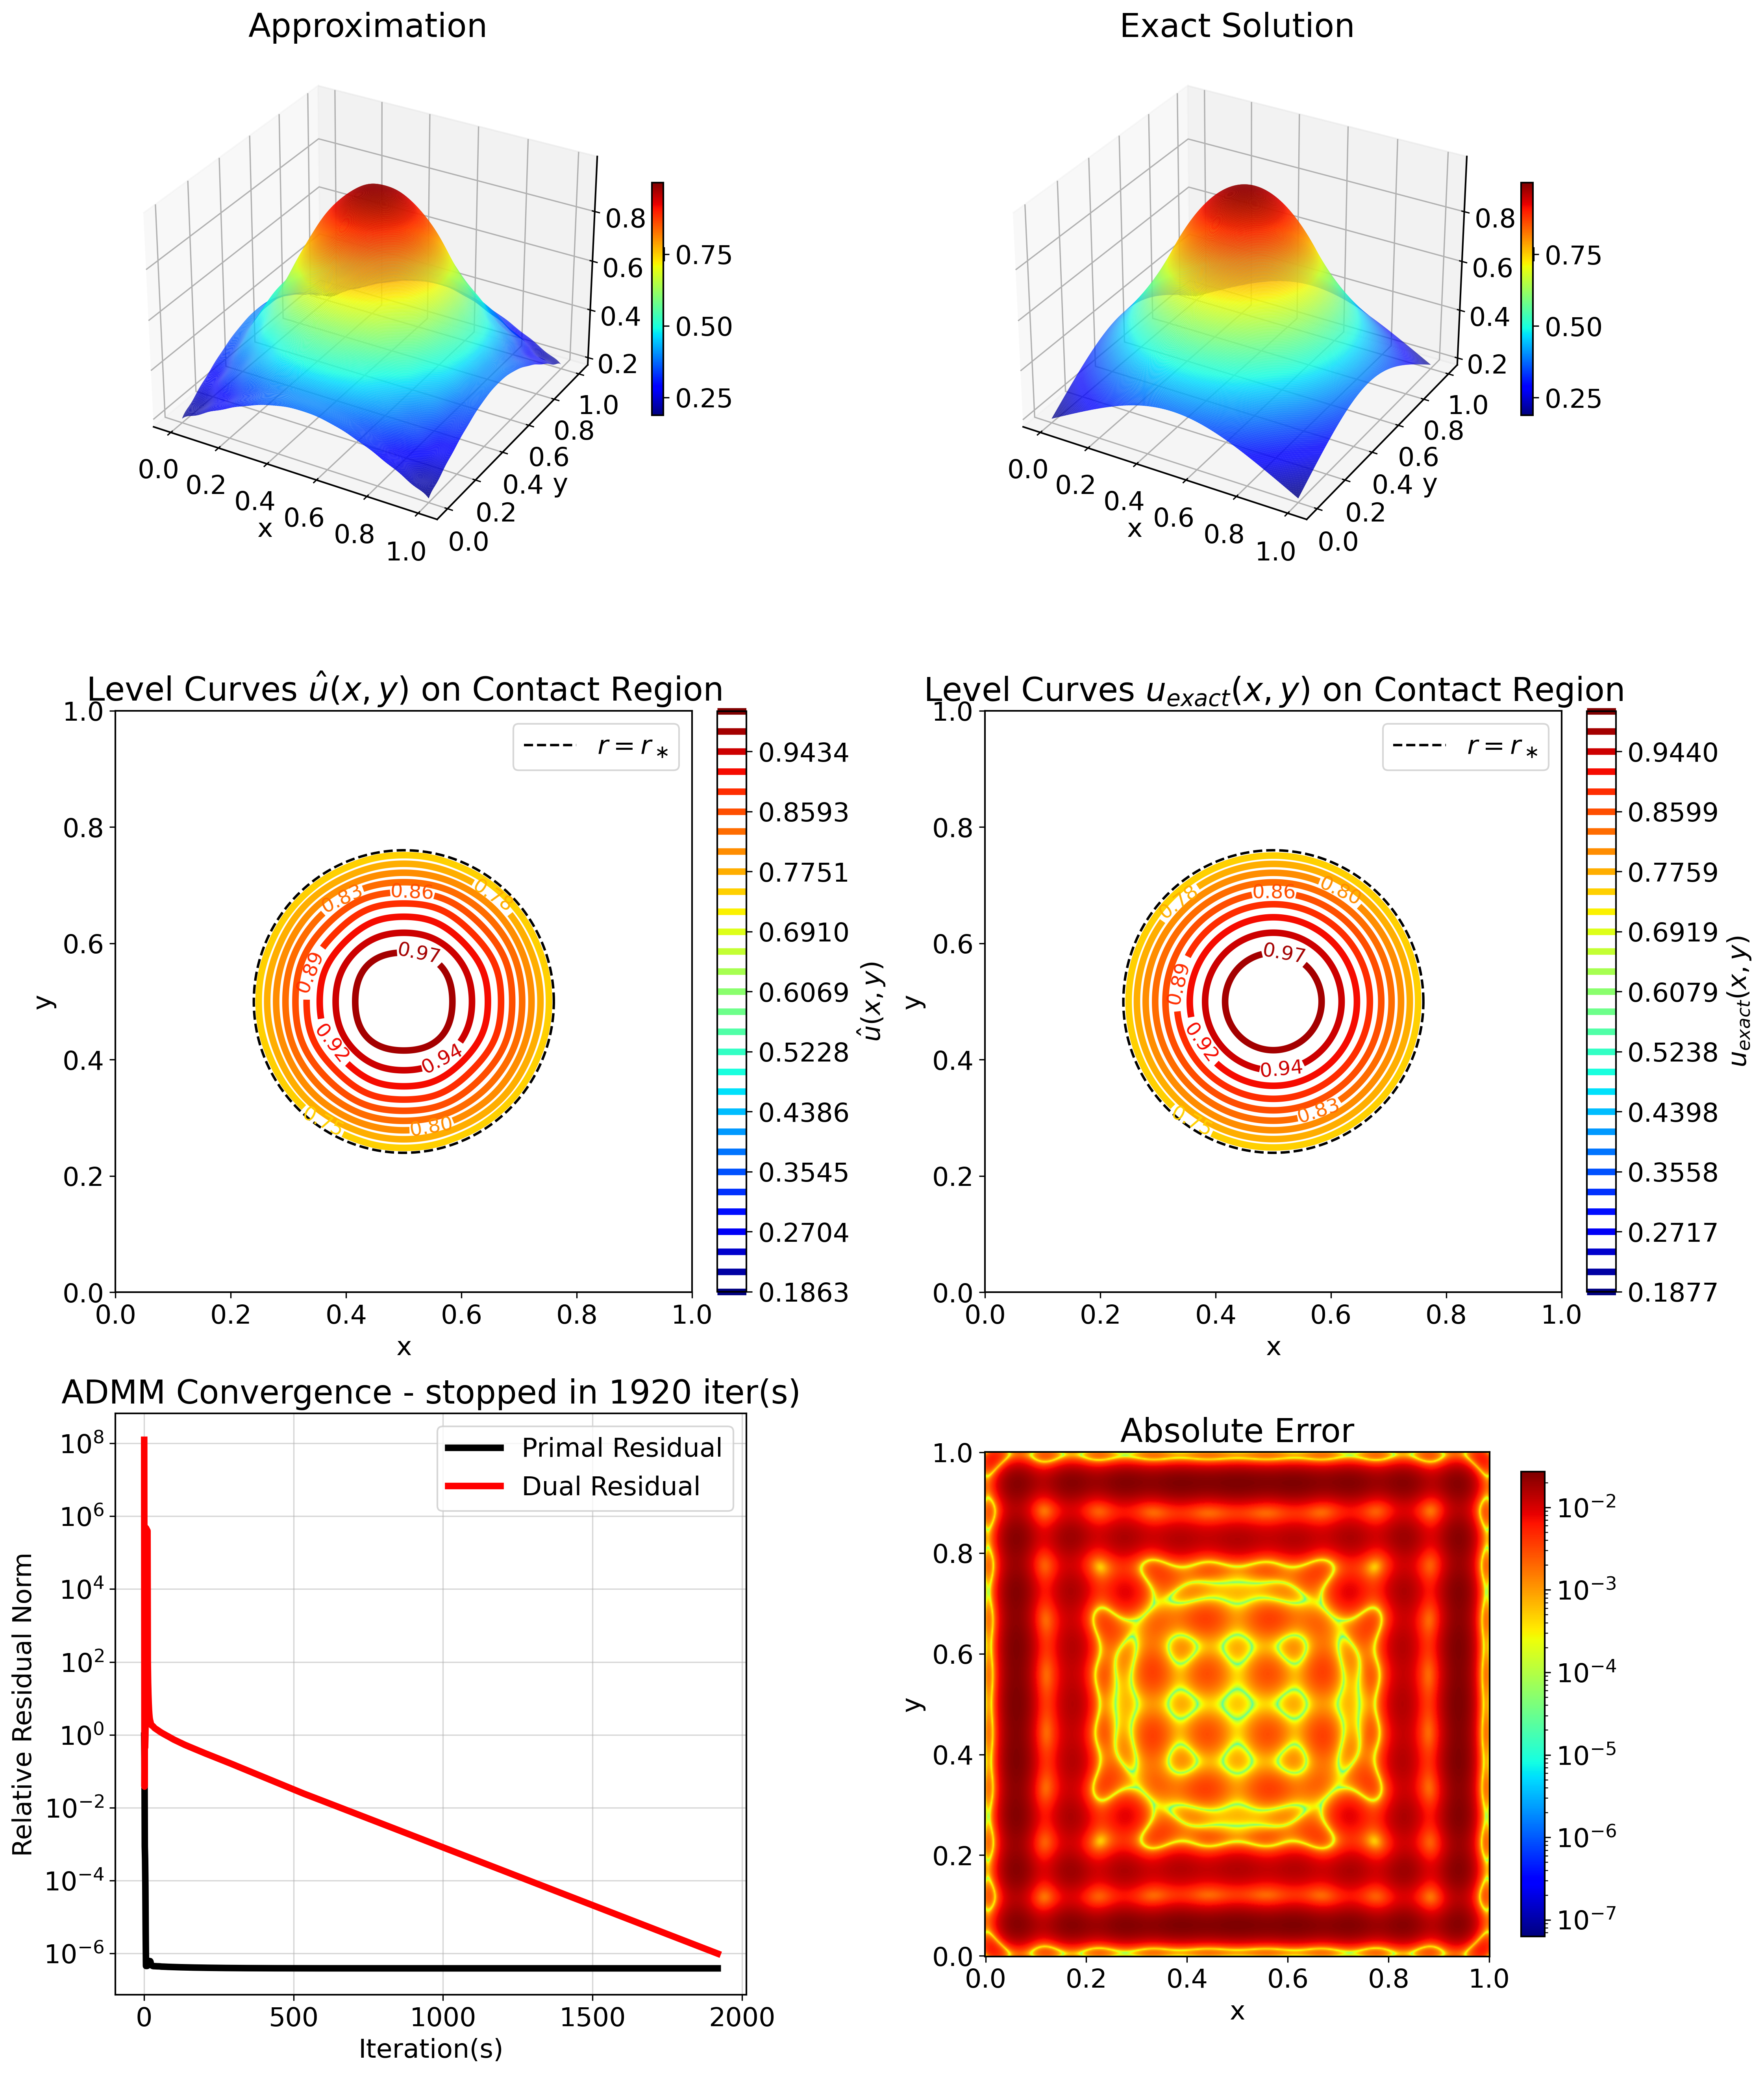

In [3]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.labelsize': 16,
    'axes.titlesize': 20,
    'axes.linewidth': 1.0,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'lines.linewidth': 4.0,
    'grid.linestyle': '-',
    'grid.alpha': 0.5,
    'figure.dpi': 300,
})


# =========================
# Relative L2 + boundary diagnostics
# =========================
hx = L / (M_plot - 1)
hy = L / (M_plot - 1)
dA = hx * hy

num = np.sum((U_rbf - U_exact)**2) * dA
den = np.sum((U_exact) ** 2) 
rel_L2 = num / max(den, 1e-300)
print(f"Relative L2 (domain): {rel_L2:.6e}")
boundary_mask_2D = boundary_mask_plot.reshape(M_plot, M_plot)

U_rbf_vec = U_rbf.ravel()
U_ex_vec  = U_exact.ravel()
bd_idx = np.where(boundary_mask_plot)[0]
bd_err_abs = np.abs(U_rbf_vec[bd_idx] - U_ex_vec[bd_idx])
print(f"Boundary mean abs error: {bd_err_abs.mean():.6e}")

import matplotlib.cm as cm
import matplotlib.colors as mcolors

# =========================
# 3D plots (jet colormap)
# =========================
fig = plt.figure(figsize=(15, 18.0), dpi = 300)

ax1 = fig.add_subplot(3, 2, 1, projection='3d')
surf1 = ax1.plot_surface(X_plot, Y_plot, U_rbf, cmap='jet', linewidth=0, antialiased=True, rstride=1, cstride=1)
#ax1.view_init(elev=30, azim=-25)
ax1.set_title('Approximation')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('u')
fig.colorbar(surf1, ax=ax1, shrink=0.4, pad=0.05)

ax2 = fig.add_subplot(3, 2, 2, projection='3d')
surf2 = ax2.plot_surface(X_plot, Y_plot, U_exact, cmap='jet', linewidth=0, antialiased=True, rstride=1, cstride=1)
#ax2.view_init(elev=30, azim=-25)
ax2.set_title('Exact Solution')
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('u')
fig.colorbar(surf2, ax=ax2, shrink=0.4, pad=0.05)


# -------------------------
# Contact-region level curves for ax3 (approx) and ax4 (exact)
# -------------------------
Cx, Cy = CENTER
Rgrid = np.hypot(X_plot - Cx, Y_plot - Cy)          # radial distances on grid
theta = np.linspace(0, 2*np.pi, 400)
mask_contact_exact = (Rgrid <= r_star)
U_exact_contact = np.ma.masked_where(~mask_contact_exact, U_exact)
U_rbf_contact = np.ma.masked_where(~mask_contact_exact, U_rbf)

# Row 2: Level curves of U exact 
ax3 = fig.add_subplot(3, 2, 4)
levels = np.linspace(U_exact.min(), U_exact.max(), 30)
cs = ax3.contour(X_plot, Y_plot, U_exact_contact, levels=levels, cmap='jet')
ax3.plot(Cx + r_star*np.cos(theta), Cy + r_star*np.sin(theta), 'k--', lw=1.5, label=r'$r=r_\ast$')
ax3.clabel(cs, inline=True, fontsize=12, fmt="%.2f")   # optional labels on curves
ax3.set_title('Level Curves $u_{exact}(x,y)$ on Contact Region')
ax3.set_xlabel('x'); ax3.set_ylabel('y')
ax3.legend()
fig.colorbar(cs, ax=ax3, fraction=0.046, pad=0.04, label='$u_{exact}(x,y)$')

# Level curves of U approximate 
ax4 = fig.add_subplot(3, 2, 3)
levels = np.linspace(U_rbf.min(), U_rbf.max(), 30)
cs = ax4.contour(X_plot, Y_plot, U_rbf_contact, levels=levels, cmap='jet')
ax4.plot(Cx + r_star*np.cos(theta), Cy + r_star*np.sin(theta), 'k--', lw=1.5, label=r'$r=r_\ast$')
ax4.clabel(cs, inline=True, fontsize=12, fmt="%.2f")   # optional labels on curves
ax4.set_title('Level Curves $\hat{u}(x,y)$ on Contact Region')
ax4.legend()
ax4.set_xlabel('x'); ax4.set_ylabel('y')
fig.colorbar(cs, ax=ax4, fraction=0.046, pad=0.04, label='$\hat{u}(x,y)$')




# Row 3: ADMM Residuals
ax5 = fig.add_subplot(3, 2, 5)
ax5.semilogy(primal_residuals, label='Primal Residual', color = 'black')
ax5.semilogy(dual_residuals, label='Dual Residual', color = 'red')
ax5.set_title(f'ADMM Convergence - stopped in {it + 1:2d} iter(s)')
ax5.set_xlabel('Iteration(s)'); ax5.set_ylabel('Relative Residual Norm')
ax5.legend(); ax5.grid(True)



hx = L / (M_plot - 1)
hy = L / (M_plot - 1)

ax6 = fig.add_subplot(3, 2, 6)
abs_err = np.abs(U_rbf - U_exact)
norm = mcolors.LogNorm(vmin=abs_err.min(), vmax=abs_err.max())
cs = ax6.imshow(
    abs_err, origin='lower',
    extent=[0 - hx/2, 1 + hx/2, 0 - hy/2, 1 + hy/2],
    cmap='jet', norm=norm,
    interpolation='bicubic'   # options: 'bilinear', 'bicubic', 'hanning', ...
)


ax6.set_aspect('equal', adjustable='box')
ax6.set_title('Absolute Error')
ax6.set_xlabel('x'); ax6.set_ylabel('y')
fig.colorbar(cs, ax=ax6, shrink=0.8, pad=0.05)

plt.tight_layout()
plt.savefig('./Outputs/2D_Obstacle/Psi_Cont/fig1_obstacle_2D_smooth.png')
plt.show()